In [ ]:
import time
import numpy as np

from mandelbrot import (
    mandelbrot_naive,
    mandelbrot_numpy,
    mandelbrot_numba,
    mandelbrot_numba_basic,
    time_call,
    profile_call,
    line_profile_call,
)

In [7]:
grid_sizes = [1024] #[256, 512, 1024, 2048, 4096]

max_iter = 100
xmin, xmax = -2.0, 1.0
ymin, ymax = -1.5, 1.5

In [8]:
def best_of_5(func, *args):
    times = []
    result = None
    for _ in range(5):
        t0 = time.perf_counter()
        result = func(*args)
        t1 = time.perf_counter()
        times.append(t1 - t0)
    return min(times), result

def checksum(out):
    if isinstance(out, list):
        return sum(sum(row) for row in out)
    return int(np.sum(out))

In [9]:
implementations = [
    ("naive", mandelbrot_naive),
    ("numpy", mandelbrot_numpy),
    ("numba_basic_f64", lambda w,h,mi,x0,x1,y0,y1: mandelbrot_numba_basic(w,h,mi,x0,x1,y0,y1, dtype=np.float64)),
    ("numba_basic_f32", lambda w,h,mi,x0,x1,y0,y1: mandelbrot_numba_basic(w,h,mi,x0,x1,y0,y1, dtype=np.float32)),
    ("numba", mandelbrot_numba),
]

# Warm up numba kernels (avoid counting compilation time)
warm_args = (256, 256, max_iter, xmin, xmax, ymin, ymax)
mandelbrot_numba(*warm_args)
mandelbrot_numba_basic(*warm_args)  # float64 default
mandelbrot_numba_basic(*warm_args, dtype=np.float32)

array([[1, 1, 1, ..., 2, 2, 2],
       [1, 1, 1, ..., 2, 2, 2],
       [1, 1, 1, ..., 2, 2, 2],
       ...,
       [1, 1, 1, ..., 2, 2, 2],
       [1, 1, 1, ..., 2, 2, 2],
       [1, 1, 1, ..., 2, 2, 2]], shape=(256, 256), dtype=int32)

 grid  implementation   best_of_5 (s)  speedup_vs_naive      checksum
----------------------------------------------------------------------------
 1024  naive                 2.894041              1.00      21959734
 1024  numpy                 0.626572              4.62      21959734
 1024  numba_basic_f64        0.051210             56.51      21959734
 1024  numba_basic_f32        0.051102             56.63      21959734
 1024  numba                 0.017284            167.44      21959734
----------------------------------------------------------------------------


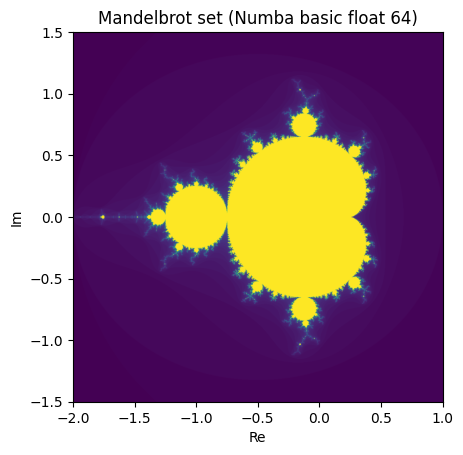

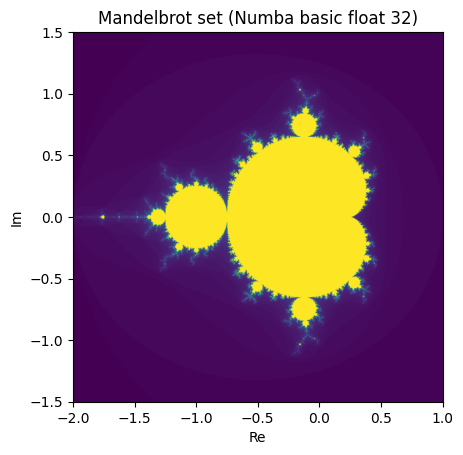

In [10]:
print(f"{'grid':>5}  {'implementation':<14}  {'best_of_5 (s)':>14}  {'speedup_vs_naive':>16}  {'checksum':>12}")
print("-" * 76)

for n in grid_sizes:
    width = height = n
    args = (width, height, max_iter, xmin, xmax, ymin, ymax)

    naive_time, naive_out = best_of_5(mandelbrot_naive, *args)
    naive_chk = checksum(naive_out)

    print(f"{n:>5}  {'naive':<14}  {naive_time:>14.6f}  {1.0:>16.2f}  {naive_chk:>12}")

    for name, fn in implementations[1:]:
        tbest, out = best_of_5(fn, *args)
        chk = checksum(out)
        speedup = naive_time / tbest
        print(f"{n:>5}  {name:<14}  {tbest:>14.6f}  {speedup:>16.2f}  {chk:>12}")

    print("-" * 76)

#print images of mandelbrot numba basic float64 and float32 for visual verification
import matplotlib.pyplot as plt
numba_basic = mandelbrot_numba_basic(width, height, max_iter, xmin, xmax, ymin, ymax, dtype=np.float64)
plt.figure()
plt.imshow(numba_basic, extent=(xmin, xmax, ymin, ymax), origin="lower")
plt.title("Mandelbrot set (Numba basic float 64)")
plt.xlabel("Re")
plt.ylabel("Im")
plt.show()

numba_basic_f32 = mandelbrot_numba_basic(width, height, max_iter, xmin, xmax, ymin, ymax, dtype=np.float32)
plt.figure()
plt.imshow(numba_basic_f32, extent=(xmin, xmax, ymin, ymax), origin="lower")
plt.title("Mandelbrot set (Numba basic float 32)")
plt.xlabel("Re")
plt.ylabel("Im")
plt.show()


In [ ]:
# Profiling & Timing

# Line-profile naive
naive_data = line_profile_call(
    "mandelbrot (naive Python)",
    mandelbrot_naive,
    width, height, max_iter, xmin, xmax, ymin, ymax
)

time_call(
    "mandelbrot (naive)",
    mandelbrot_naive,
    width, height, max_iter, xmin, xmax, ymin, ymax
)

# NumPy profiling
numpy_data = profile_call(
    "mandelbrot (NumPy)",
    mandelbrot_numpy,
    width, height, max_iter, xmin, xmax, ymin, ymax,
    top=100
)

time_call(
    "mandelbrot (NumPy)",
    mandelbrot_numpy,
    width, height, max_iter, xmin, xmax, ymin, ymax
)

# Numba naive-loop and profiling (warmed up)
mandelbrot_numba_basic(width, height, max_iter, xmin, xmax, ymin, ymax, np.float64)

numba_basic = profile_call(
    "mandelbrot (Numba @njit naive loop, warmed up)",
    mandelbrot_numba_basic,
    width, height, max_iter, xmin, xmax, ymin, ymax, np.float64,
    top=100
)

time_call(
    "mandelbrot (Numba @njit naive loop, warmed up)",
    mandelbrot_numba_basic,
    width, height, max_iter, xmin, xmax, ymin, ymax, np.float64
)

# Mini report/questions
## Hardware:  
Apple M1 Pro  
10-core CPU  
16-core Neural Engiene  
16gb unified memory  

## Reflection/milestones:  
### Milestone 1   
### Which function takes most total time?  
Out of five runs, the naive took almost 3 seconds, with the other implementations doing inceasingly and notably better

### Are there functions called surprisingly many times?  
Again for the naive, the inner loop is called almost 23 million times, which seems like a lot.

### How does the NumPy profile compare to naive?  
It is faster than the naive, and uses a lot fewer function calls

### Where does NumPy spend its time?
Allmost all time is spendt in "1    0.646    0.646    0.650    0.650 mandelbrot.py:115(mandelbrot_numpy)", with the rest being >0.003

### Milestone 2  
### cProfile on naive vs NumPy: How many functions appear in each profile? What does this difference tell you about where the work actually happens?  
For the moment, I could apperently not get the cProfile to work for the naive implementation, but i am looking into it (probably missed something stupid)
The numpy implementation had 72 function calls, and the naive should have fewer.
Given how numpy is implemented, it offloads the loop work to the compiled code, whereas the naive uses the interpreter.

### line profiler on naive: Which lines dominate runtime? What fraction of total time is spent in the inner loop?
The line with the while loop and math inside (lines 74-76), uses 91,5% of the total runtime:  
    74  23008310 4538690000.0    197.3     39.4              while n < max_iter and (z.real * z.real + z.imag * z.imag) <= 4.0:
    75  21959734 3331196000.0    151.7     28.9                  z = z * z + c
    76  21959734 2709325000.0    123.4     23.5                  n += 1

### Based on your profiling results: why is NumPy faster than naive Python?
Numpy moves some of the comsuming iterative work into vectorized operations

### What would you need to change to make the naive version faster? (hint: what does line profiler tell you about the inner loop?)
1. I could move the inner loop to the compled code (e.g. numba, as done)
2. avoid using complex(), this would help a little 

### Milestone 4  
### Speed: Does float32 actually run faster than float64 on your hardware? By how much?  
 1024  numba_basic_f64        0.051210             56.51      21959734
 1024  numba_basic_f32        0.051102             56.63      21959734
float23 is about 0.2% faster

### float16: Try it with NumPy — is it faster than float32? (It may not be, since NumPy promotes to float32 internally.) Numba may refuse to compile float16 — if so, skip it and note why.  
I could not get float16 to work.
often is float16 not faster, as many packages often promote float16 to float32, and are not optimized for float16, though float16 could offer a quater of the memory


### Visual quality: Zoom in on a detailed region of the Mandelbrot set. Can you see artefacts with float16? What about float32?
I really do not see a difference between float32 and float64.
This is supported by the "checksums", which are the same, though this does not insure identical pictures, but it should validate that identical work is done

### Recommendation: Based on what you observe, which precision would you choose for production use, and why?
float64 would offer more safety and at a not very different speed, though if relevant, float32 would be more memory efficient


## Reflection  
Well, i was quite surprised of the tools available to analyse the code, but of course it exist - it is relevant, which is supported by the optimization of these "simple" implementations.
Especially when scaling the grid size, the effect is clearly visible. With the gridsize of 4096, the naive imlementation took around 46 seconds, while the numba implementation (with warmup) took only 0.28 seceond (both are best of 5 runs).
Also seeing the impact of a nested loop in hard numbers, was surprising. I knew you are supposed to avoid nested loops, but it has always been in figuartive numbers
I knew numpy can be used for vectorized operations and somehow though that was enough, but using Numba and the compiler surprised me a lot with the difference.
